In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation, SegformerConfig

SEED = 42

def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32        = False
    print(f"Seed set to {seed}")

seed_everything(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
assert torch.cuda.is_available(), "GPU not available"
print("Cell 1 passed")

Seed set to 42
Using device: cuda
Cell 1 passed


In [2]:
class EWSDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root = Path(root_dir) / split
        self.transform = transform
        all_files = list(self.root.glob("*.png"))
        self.images = sorted([f for f in all_files if '_mask' not in f.name])
        print(f"[{split}] Found {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path  = self.images[idx]
        mask_path = self.root / img_path.name.replace('.png', '_mask.png')

        image = np.array(Image.open(img_path).convert('RGB'))
        mask  = np.array(Image.open(mask_path))[:, :, 0]
        mask  = (mask < 128).astype(np.float32) 

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']
            return image, mask.unsqueeze(0)

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask  = torch.from_numpy(mask).unsqueeze(0)
        return image, mask

# 测试
_ds = EWSDataset(".", "train", transform=None)
_img, _mask = _ds[0]

assert isinstance(_img,  torch.Tensor), f"image should be Tensor, got {type(_img)}"
assert isinstance(_mask, torch.Tensor), f"mask should be Tensor, got {type(_mask)}"
assert _img.shape  == (3, 350, 350), f"image shape error: {_img.shape}"
assert _mask.shape == (1, 350, 350), f"mask shape error: {_mask.shape}"
assert set(_mask.unique().tolist()).issubset({0.0, 1.0}), f"mask values error: {_mask.unique()}"

print(f"  image shape : {_img.shape}, dtype: {_img.dtype}")
print(f"  mask  shape : {_mask.shape}, unique: {_mask.unique()}")
print("Cell 2 passed")

[train] Found 142 images
  image shape : torch.Size([3, 350, 350]), dtype: torch.float32
  mask  shape : torch.Size([1, 350, 350]), unique: tensor([0., 1.])
Cell 2 passed


In [3]:
DATASET_ROOT = "."
IMG_SIZE     = 256
BATCH_SIZE   = 8

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

def build_dataloaders(seed=42):
    train_ds = EWSDataset(DATASET_ROOT, 'train',      transform=train_transform)
    val_ds   = EWSDataset(DATASET_ROOT, 'validation', transform=val_transform)
    test_ds  = EWSDataset(DATASET_ROOT, 'test',       transform=val_transform)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = build_dataloaders(SEED)

# 测试
_imgs, _masks = next(iter(train_loader))

assert _imgs.shape  == (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE), f"image batch shape error: {_imgs.shape}"
assert _masks.shape == (BATCH_SIZE, 1, IMG_SIZE, IMG_SIZE), f"mask batch shape error: {_masks.shape}"
assert _imgs.dtype  == torch.float32, f"image dtype error: {_imgs.dtype}"
assert _masks.dtype == torch.float32, f"mask dtype error: {_masks.dtype}"

print(f"  train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
print(f"  batch image shape : {_imgs.shape}")
print(f"  batch mask  shape : {_masks.shape}")
print(f"  mask unique vals  : {_masks.unique()}")
print("Cell 3 passed")

[train] Found 142 images
[validation] Found 24 images
[test] Found 24 images
  train=142, val=24, test=24
  batch image shape : torch.Size([8, 3, 256, 256])
  batch mask  shape : torch.Size([8, 1, 256, 256])
  mask unique vals  : tensor([0., 1.])
Cell 3 passed


In [4]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

# 测试
model.eval()
with torch.no_grad():
    _dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out   = model(_dummy)

assert _out.shape == (2, 1, IMG_SIZE, IMG_SIZE), f"output shape error: {_out.shape}"
assert next(model.parameters()).is_cuda, "model not on GPU"

print(f"  encoder      : resnet34 (pretrained on ImageNet)")
print(f"  input  shape : {_dummy.shape}")
print(f"  output shape : {_out.shape}")
print(f"  model device : {next(model.parameters()).device}")
print(f"  total params : {sum(p.numel() for p in model.parameters()):,}")
print("Cell 4 passed")

  encoder      : resnet34 (pretrained on ImageNet)
  input  shape : torch.Size([2, 3, 256, 256])
  output shape : torch.Size([2, 1, 256, 256])
  model device : cuda:0
  total params : 24,436,369
Cell 4 passed


In [5]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc="Train", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(images), masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, loss_fn, threshold=0.5):
    model.eval()
    total_loss = 0
    tp_s = fp_s = fn_s = tn_s = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            preds = model(images)
            total_loss += loss_fn(preds, masks).item()
            tp, fp, fn, tn = smp.metrics.get_stats(
                torch.sigmoid(preds), masks.long(), mode='binary', threshold=threshold)
            tp_s += tp.sum(); fp_s += fp.sum()
            fn_s += fn.sum(); tn_s += tn.sum()
    iou  = smp.metrics.iou_score(tp_s, fp_s, fn_s, tn_s, reduction="micro").item()
    f1   = smp.metrics.f1_score(tp_s,  fp_s, fn_s, tn_s, reduction="micro").item()
    prec = smp.metrics.precision(tp_s, fp_s, fn_s, tn_s, reduction="micro").item()
    rec  = smp.metrics.recall(tp_s,   fp_s, fn_s, tn_s,  reduction="micro").item()
    return total_loss / len(loader), iou, f1, prec, rec

def run_experiment(seed, encoder_name="resnet34", loss_fn=None,
                   epochs=30, save_path="best_model.pth", lr=1e-4):
    seed_everything(seed)
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = build_dataloaders(seed)

    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()

    best_iou = 0
    history  = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}
    start    = time.time()

    for epoch in range(1, epochs + 1):
        t_loss                     = train_one_epoch(model, train_loader, optimizer, loss_fn)
        v_loss, iou, f1, prec, rec = evaluate(model, val_loader, loss_fn)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_iou'].append(iou)
        history['val_f1'].append(f1)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"TrainLoss {t_loss:.4f} | ValLoss {v_loss:.4f} | "
              f"IoU {iou:.4f} | F1 {f1:.4f} | Prec {prec:.4f} | Rec {rec:.4f}")

        if iou > best_iou:
            best_iou = iou
            torch.save(model.state_dict(), save_path)
            print(f"  -> best model saved (IoU={best_iou:.4f})")

    train_time = time.time() - start
    return model, history, train_time, best_iou, \
           train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

print("Cell 5 passed")

Cell 5 passed


In [6]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        preds = preds.contiguous().view(preds.size(0), -1)
        targets = targets.contiguous().view(targets.size(0), -1).float()

        intersection = (preds * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            preds.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )

        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth=smooth)
        self.bce_weight = bce_weight
        self.smooth = smooth

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)
        dice_loss = self.dice(preds, targets)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


DEFAULT_BCE_WEIGHT = 0.5
DEFAULT_DICE_SMOOTH = 1.0

# 测试
_loss_fn_test = BCEDiceLoss(
    bce_weight=DEFAULT_BCE_WEIGHT,
    smooth=DEFAULT_DICE_SMOOTH
)
_dummy_pred = torch.randn(2, 1, IMG_SIZE, IMG_SIZE)
_dummy_mask = torch.randint(0, 2, (2, 1, IMG_SIZE, IMG_SIZE)).float()
_loss_val = _loss_fn_test(_dummy_pred, _dummy_mask)

assert 0 <= _loss_val.item() <= 2, f"loss out of range: {_loss_val.item()}"
print(f"BCEDiceLoss test value: {_loss_val.item():.4f}")
print("Cell 6 passed")

BCEDiceLoss test value: 0.6527
Cell 6 passed


In [7]:
# resnet34 + BCE (baseline)
print("=" * 50)
print("Config 1: resnet34 + BCE (30ep)")
print("=" * 50)
_, _, train_time_v1, best_iou_v1, _, _, _, _, _, _ = run_experiment(
    seed=SEED,
    encoder_name="resnet34",
    loss_fn=nn.BCEWithLogitsLoss(),
    epochs=30,
    save_path="best_unet_v1.pth"
)
print(f"Best Val IoU: {best_iou_v1:.4f} | Train time: {train_time_v1:.1f}s")

# resnet34 + BCE+Dice
print("=" * 50)
print("Config 2: resnet34 + BCE+Dice (30ep)")
print("=" * 50)
_, _, train_time_v2, best_iou_v2, _, _, _, _, _, _ = run_experiment(
    seed=SEED,
    encoder_name="resnet34",
    loss_fn=BCEDiceLoss(bce_weight=0.5),
    epochs=30,
    save_path="best_unet_v2.pth"
)
print(f"Best Val IoU: {best_iou_v2:.4f} | Train time: {train_time_v2:.1f}s")

# resnet50 + BCE+Dice
print("=" * 50)
print("Config 3: resnet50 + BCE+Dice (30ep)")
print("=" * 50)
_, _, train_time_v3, best_iou_v3, _, _, _, _, _, _ = run_experiment(
    seed=SEED,
    encoder_name="resnet50",
    loss_fn=BCEDiceLoss(bce_weight=0.5),
    epochs=30,
    save_path="best_unet_v3.pth"
)
print(f"Best Val IoU: {best_iou_v3:.4f} | Train time: {train_time_v3:.1f}s")

# resnet34 + BCE+Dice + 50ep
print("=" * 50)
print("Config 4: resnet34 + BCE+Dice (50ep)")
print("=" * 50)
_, _, train_time_v4, best_iou_v4, _, _, _, _, _, _ = run_experiment(
    seed=SEED,
    encoder_name="resnet34",
    loss_fn=BCEDiceLoss(bce_weight=0.5),
    epochs=50,
    save_path="best_unet_v4.pth"
)
print(f"Best Val IoU: {best_iou_v4:.4f} | Train time: {train_time_v4:.1f}s")

# resnet34 + BCE+Dice + 50ep + lr=3e-4
print("=" * 50)
print("Config 5: resnet34 + BCE+Dice (50ep, lr=3e-4)")
print("=" * 50)
_, _, train_time_v5, best_iou_v5, _, _, _, _, _, _ = run_experiment(
    seed=SEED,
    encoder_name="resnet34",
    loss_fn=BCEDiceLoss(bce_weight=0.5),
    epochs=50,
    save_path="best_unet_v5.pth",
    lr=3e-4
)
print(f"Best Val IoU: {best_iou_v5:.4f} | Train time: {train_time_v5:.1f}s")

# resnet34 + BCE+Dice + 50ep + lr=3e-5
print("=" * 50)
print("Config 6: resnet34 + BCE+Dice (50ep, lr=3e-5)")
print("=" * 50)
_, _, train_time_v6, best_iou_v6, _, _, _, _, _, _ = run_experiment(
    seed=SEED,
    encoder_name="resnet34",
    loss_fn=BCEDiceLoss(bce_weight=0.5),
    epochs=50,
    save_path="best_unet_v6.pth",
    lr=3e-5
)
print(f"Best Val IoU: {best_iou_v6:.4f} | Train time: {train_time_v6:.1f}s")

print("\n" + "=" * 50)
print("调参完整对比")
print("=" * 50)
print(f"resnet34 + BCE       (30ep, lr=1e-4) : Val IoU = {best_iou_v1:.4f}")
print(f"resnet34 + BCE+Dice  (30ep, lr=1e-4) : Val IoU = {best_iou_v2:.4f}")
print(f"resnet50 + BCE+Dice  (30ep, lr=1e-4) : Val IoU = {best_iou_v3:.4f}")
print(f"resnet34 + BCE+Dice  (50ep, lr=1e-4) : Val IoU = {best_iou_v4:.4f}")
print(f"resnet34 + BCE+Dice  (50ep, lr=3e-4) : Val IoU = {best_iou_v5:.4f}")
print(f"resnet34 + BCE+Dice  (50ep, lr=3e-5) : Val IoU = {best_iou_v6:.4f}")


all_configs = {
    "best_unet_v1.pth": best_iou_v1,
    "best_unet_v2.pth": best_iou_v2,
    "best_unet_v3.pth": best_iou_v3,
    "best_unet_v4.pth": best_iou_v4,
    "best_unet_v5.pth": best_iou_v5,
    "best_unet_v6.pth": best_iou_v6,
}

best_model_path = max(all_configs, key=all_configs.get)
best_model_iou  = all_configs[best_model_path]
print(f"\nBest model path : {best_model_path}")
print(f"Best model IoU  : {best_model_iou:.4f}")

Config 1: resnet34 + BCE (30ep)
Seed set to 42
[train] Found 142 images
[validation] Found 24 images
[test] Found 24 images


Epoch 01/30 | TrainLoss 0.7466 | ValLoss 1.2633 | IoU 0.5024 | F1 0.6688 | Prec 0.5226 | Rec 0.9286
  -> best model saved (IoU=0.5024)


Epoch 02/30 | TrainLoss 0.5599 | ValLoss 0.7720 | IoU 0.5556 | F1 0.7143 | Prec 0.5814 | Rec 0.9262
  -> best model saved (IoU=0.5556)


Epoch 03/30 | TrainLoss 0.4761 | ValLoss 0.4391 | IoU 0.6252 | F1 0.7694 | Prec 0.6737 | Rec 0.8967
  -> best model saved (IoU=0.6252)


Epoch 04/30 | TrainLoss 0.4249 | ValLoss 0.4471 | IoU 0.6306 | F1 0.7734 | Prec 0.6598 | Rec 0.9343
  -> best model saved (IoU=0.6306)


...

Epoch 46/50 | TrainLoss 0.3420 | ValLoss 0.3244 | IoU 0.7806 | F1 0.8768 | Prec 0.8487 | Rec 0.9069
  -> best model saved (IoU=0.7806)


Epoch 47/50 | TrainLoss 0.3373 | ValLoss 0.3263 | IoU 0.7780 | F1 0.8751 | Prec 0.8315 | Rec 0.9236


Epoch 48/50 | TrainLoss 0.3394 | ValLoss 0.3355 | IoU 0.7614 | F1 0.8646 | Prec 0.8012 | Rec 0.9389


Epoch 49/50 | TrainLoss 0.3285 | ValLoss 0.3248 | IoU 0.7752 | F1 0.8734 | Prec 0.8261 | Rec 0.9265


Epoch 50/50 | TrainLoss 0.3304 | ValLoss 0.3182 | IoU 0.7802 | F1 0.8765 | Prec 0.8377 | Rec 0.9191
Best Val IoU: 0.7806 | Train time: 186.3s

调参完整对比
resnet34 + BCE       (30ep, lr=1e-4) : Val IoU = 0.7986
resnet34 + BCE+Dice  (30ep, lr=1e-4) : Val IoU = 0.7970
resnet50 + BCE+Dice  (30ep, lr=1e-4) : Val IoU = 0.7990
resnet34 + BCE+Dice  (50ep, lr=1e-4) : Val IoU = 0.8067
resnet34 + BCE+Dice  (50ep, lr=3e-4) : Val IoU = 0.8152
resnet34 + BCE+Dice  (50ep, lr=3e-5) : Val IoU = 0.7806

Best model path : best_unet_v5.pth
Best model IoU  : 0.8152


In [8]:
seed_everything(SEED)
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = build_dataloaders(SEED)

encoder_map = {
    "best_unet_v1.pth": "resnet34",
    "best_unet_v2.pth": "resnet34",
    "best_unet_v3.pth": "resnet50",
    "best_unet_v4.pth": "resnet34",
    "best_unet_v5.pth": "resnet34",
    "best_unet_v6.pth": "resnet34",
}

best_encoder = encoder_map[best_model_path]

model_final = smp.Unet(
    encoder_name=best_encoder,
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

state_dict = torch.load(best_model_path, map_location=DEVICE, weights_only=True)
model_final.load_state_dict(state_dict)
model_final.eval()
print(f"Loaded: {best_model_path} (encoder={best_encoder})")

if best_model_path == "best_unet_v1.pth":
    loss_fn_final = nn.BCEWithLogitsLoss()
else:
    loss_fn_final = BCEDiceLoss(bce_weight=0.5)

print(f"Loss function: {loss_fn_final.__class__.__name__}")

# threshold tuning
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
threshold_results = []

print("Threshold tuning on validation set:")
print("-" * 50)

with torch.no_grad():
    for t in thresholds:
        tp_s = fp_s = fn_s = tn_s = 0

        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            preds = torch.sigmoid(model_final(images))

            tp, fp, fn, tn = smp.metrics.get_stats(
                preds, masks.long(), mode='binary', threshold=t
            )

            tp_s += tp.sum()
            fp_s += fp.sum()
            fn_s += fn.sum()
            tn_s += tn.sum()

        iou  = smp.metrics.iou_score(tp_s, fp_s, fn_s, tn_s, reduction="micro").item()
        f1   = smp.metrics.f1_score(tp_s, fp_s, fn_s, tn_s, reduction="micro").item()
        prec = smp.metrics.precision(tp_s, fp_s, fn_s, tn_s, reduction="micro").item()
        rec  = smp.metrics.recall(tp_s, fp_s, fn_s, tn_s, reduction="micro").item()

        threshold_results.append((t, iou, f1, prec, rec))

        print(f"  threshold={t:.2f} | IoU={iou:.4f} | F1={f1:.4f} | "
              f"Prec={prec:.4f} | Rec={rec:.4f}")

best_threshold = max(threshold_results, key=lambda x: x[1])[0]
best_iou_thresh = max(threshold_results, key=lambda x: x[1])[1]

print("-" * 50)
print(f"Best threshold : {best_threshold:.2f}")
print(f"Best Val IoU   : {best_iou_thresh:.4f}")
print(f"Default (0.50) : {[r[1] for r in threshold_results if r[0] == 0.50][0]:.4f}")
print("Cell 8 passed")

Seed set to 42
[train] Found 142 images
[validation] Found 24 images
[test] Found 24 images
Loaded: best_unet_v5.pth (encoder=resnet34)
Loss function: BCEDiceLoss
Threshold tuning on validation set:
--------------------------------------------------
  threshold=0.30 | IoU=0.8089 | F1=0.8943 | Prec=0.8560 | Rec=0.9363
  threshold=0.35 | IoU=0.8128 | F1=0.8967 | Prec=0.8672 | Rec=0.9284
  threshold=0.40 | IoU=0.8149 | F1=0.8980 | Prec=0.8769 | Rec=0.9202
  threshold=0.45 | IoU=0.8157 | F1=0.8985 | Prec=0.8859 | Rec=0.9114
  threshold=0.50 | IoU=0.8152 | F1=0.8982 | Prec=0.8944 | Rec=0.9021
  threshold=0.55 | IoU=0.8136 | F1=0.8972 | Prec=0.9027 | Rec=0.8919
  threshold=0.60 | IoU=0.8104 | F1=0.8953 | Prec=0.9109 | Rec=0.8802
--------------------------------------------------
Best threshold : 0.45
Best Val IoU   : 0.8157
Default (0.50) : 0.8152
Cell 8 passed


In [9]:
seed_everything(SEED)
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = build_dataloaders(SEED)

start_test = time.time()
test_loss, test_iou, test_f1, test_prec, test_rec = evaluate(
    model_final, test_loader, loss_fn_final, threshold=best_threshold
)
test_time = time.time() - start_test

config_names = {
    "best_unet_v1.pth": "resnet34 + BCE       (30ep, lr=1e-4)",
    "best_unet_v2.pth": "resnet34 + BCE+Dice  (30ep, lr=1e-4)",
    "best_unet_v3.pth": "resnet50 + BCE+Dice  (30ep, lr=1e-4)",
    "best_unet_v4.pth": "resnet34 + BCE+Dice  (50ep, lr=1e-4)",
    "best_unet_v5.pth": "resnet34 + BCE+Dice  (50ep, lr=3e-4)",
    "best_unet_v6.pth": "resnet34 + BCE+Dice  (50ep, lr=3e-5)",
}

train_times = {
    "best_unet_v1.pth": train_time_v1,
    "best_unet_v2.pth": train_time_v2,
    "best_unet_v3.pth": train_time_v3,
    "best_unet_v4.pth": train_time_v4,
    "best_unet_v5.pth": train_time_v5,
    "best_unet_v6.pth": train_time_v6,
}

print("=" * 55)
print("  FINAL TEST RESULTS")
print(f"  Config    : {config_names[best_model_path]}")
print("=" * 55)
print(f"  Threshold : {best_threshold:.2f}")
print(f"  IoU       : {test_iou:.4f}")
print(f"  F1        : {test_f1:.4f}")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  Test time : {test_time:.2f}s  ({len(test_ds)} images)")
print(f"  Train time: {train_times[best_model_path]:.1f}s")
print("=" * 55)

Seed set to 42
[train] Found 142 images
[validation] Found 24 images
[test] Found 24 images
  FINAL TEST RESULTS
  Config    : resnet34 + BCE+Dice  (50ep, lr=3e-4)
  Threshold : 0.45
  IoU       : 0.8011
  F1        : 0.8896
  Precision : 0.8778
  Recall    : 0.9016
  Test time : 0.36s  (24 images)
  Train time: 190.8s


In [10]:
def visualize_predictions(model, dataset, save_dir="predictions_unet", seed=42):
    import os
    os.makedirs(save_dir, exist_ok=True)

    model.eval()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        for idx in range(len(dataset)):
            img, mask = dataset[idx]
            pred     = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE)))
            pred_bin = (pred.squeeze().detach().cpu().numpy() > best_threshold).astype(np.uint8)

            img_show = img.detach().permute(1, 2, 0).numpy() * std + mean
            img_show = np.clip(img_show, 0, 1)

            fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

            axes[0].imshow(img_show)
            axes[0].set_title("Image")
            axes[0].axis('off')

            axes[1].imshow(mask.squeeze().numpy(), cmap='gray')
            axes[1].set_title("Ground Truth")
            axes[1].axis('off')

            axes[2].imshow(pred_bin, cmap='gray')
            axes[2].set_title(f"Prediction (t={best_threshold:.2f})")
            axes[2].axis('off')

            fname = dataset.images[idx].stem
            plt.suptitle(f"U-Net | {fname} | IoU threshold={best_threshold:.2f}", y=1.01)
            plt.tight_layout()
            plt.savefig(f"{save_dir}/{fname}.png", dpi=150, bbox_inches='tight')
            plt.close()

    print(f"  saved {len(dataset)} images to '{save_dir}/'")

visualize_predictions(model_final, test_ds)
print("Cell 9 passed")

  saved 24 images to 'predictions_unet/'
Cell 9 passed


In [13]:
from pathlib import Path
import csv
from PIL import Image

model_final.eval()

save_root = Path("unet_test_outputs")
pred_dir = save_root / "pred_masks"
gt_dir = save_root / "gt_masks"

pred_dir.mkdir(parents=True, exist_ok=True)
gt_dir.mkdir(parents=True, exist_ok=True)

per_image_rows = []

with torch.no_grad():
    for idx in range(len(test_ds)):
        img, mask = test_ds[idx]
        file_name = test_ds.images[idx].name
        stem = Path(file_name).stem

        pred = torch.sigmoid(model_final(img.unsqueeze(0).to(DEVICE)))
        pred_bin = (pred.squeeze().cpu().numpy() > best_threshold).astype(np.uint8)

        gt_mask = (mask.squeeze().cpu().numpy() * 255).astype(np.uint8)
        pred_mask = (pred_bin * 255).astype(np.uint8)

        gt_mask_350 = np.array(
            Image.fromarray(gt_mask).resize((350, 350), Image.NEAREST)
        )
        pred_mask_350 = np.array(
            Image.fromarray(pred_mask).resize((350, 350), Image.NEAREST)
        )

        Image.fromarray(gt_mask_350).save(gt_dir / f"{stem}_gt.png")
        Image.fromarray(pred_mask_350).save(pred_dir / f"{stem}_pred.png")

        gt_tensor = torch.from_numpy((gt_mask_350 > 0).astype(np.uint8)).unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred_tensor = torch.from_numpy((pred_mask_350 > 0).astype(np.uint8)).unsqueeze(0).unsqueeze(0).to(DEVICE)

        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_tensor,
            gt_tensor.long(),
            mode="binary"
        )
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()

        per_image_rows.append([idx, file_name, round(iou, 4)])

with open(save_root / "per_image_iou.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["idx", "file_name", "iou"])
    writer.writerows(per_image_rows)

print(f"Saved per-image outputs to: {save_root.resolve()}")
print("Cell 10 passed")



Saved per-image outputs to: C:\Users\loy\Desktop\DL ipynb\unet_test_outputs
Cell 10 passed


Per-image IoU (test set):
  idx=16 | IoU=0.3399 | FPWW0180374_RGB1_20170222_133502_6.png
  idx=17 | IoU=0.4526 | FPWW0180375_RGB1_20170222_133519_6.png
  idx=01 | IoU=0.5477 | FPWW0180049_RGB1_20170315_102908_6.png
  idx=06 | IoU=0.5486 | FPWW0180094_RGB1_20170308_114711_6.png
  idx=22 | IoU=0.5689 | FPWW0180741_RGB1_20170308_135245_6.png
  idx=00 | IoU=0.6122 | FPWW0180049_RGB1_20170308_113954_6.png
  idx=02 | IoU=0.6247 | FPWW0180049_RGB1_20170329_143149_6.png
  idx=23 | IoU=0.6628 | FPWW0180755_RGB1_20170323_173949_6.png
  idx=11 | IoU=0.6688 | FPWW0180367_RGB1_20170323_154909_6.png
  idx=12 | IoU=0.6832 | FPWW0180367_RGB1_20170329_143316_6.png
  idx=08 | IoU=0.7251 | FPWW0180139_RGB1_20170412_134921_6.png
  idx=20 | IoU=0.7274 | FPWW0180608_RGB1_20170517_164913_6.png
  idx=05 | IoU=0.7428 | FPWW0180049_RGB1_20170517_142522_6.png
  idx=10 | IoU=0.7448 | FPWW0180357_RGB1_20170405_173042_6.png
  idx=03 | IoU=0.7706 | FPWW0180049_RGB1_20170412_132427_6.png
  idx=14 | IoU=0.8022 | FPWW0

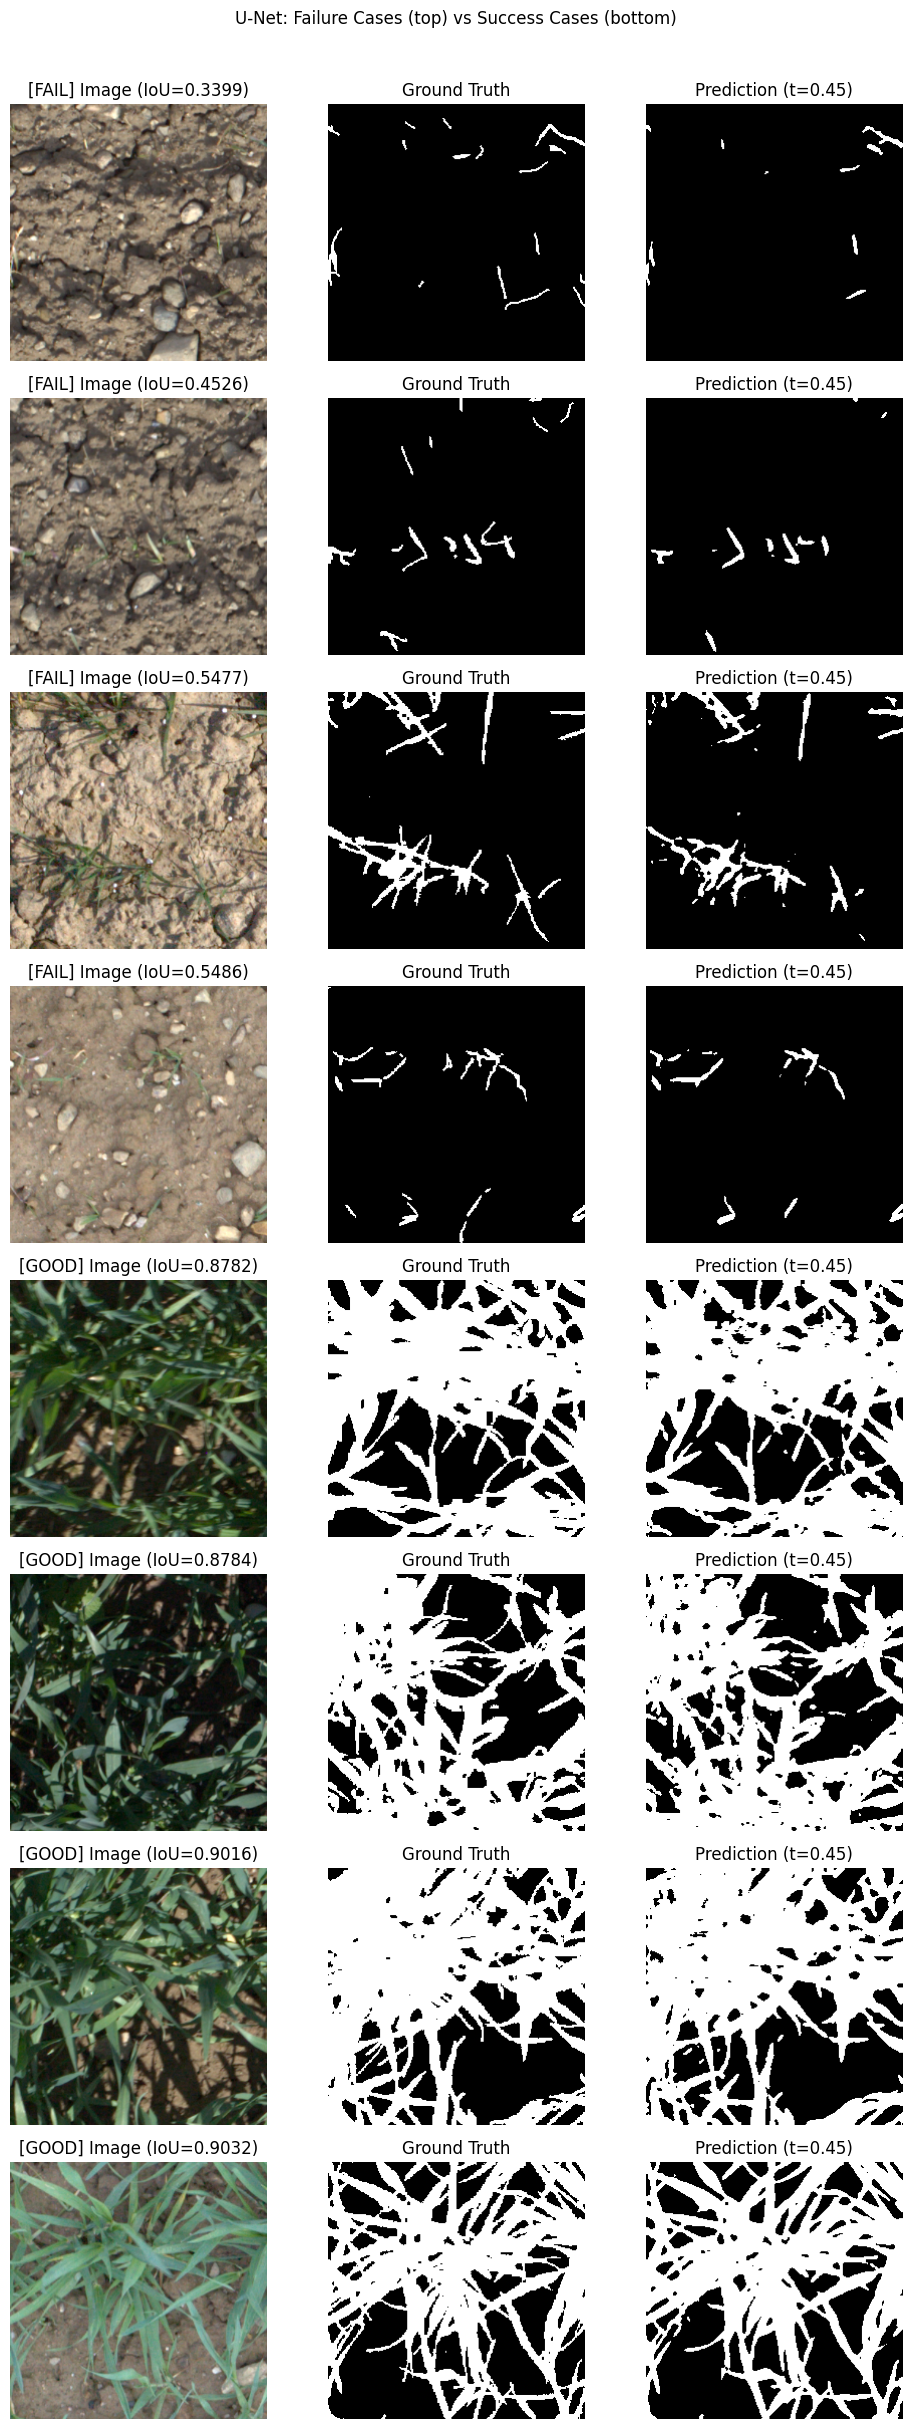

Failure analysis saved
Cell 11 passed


In [12]:
model_final.eval()
per_image_results = []

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for idx in range(len(test_ds)):
        img, mask = test_ds[idx]
        pred = torch.sigmoid(model_final(img.unsqueeze(0).to(DEVICE)))
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred, mask.unsqueeze(0).long().to(DEVICE),
            mode='binary', threshold=best_threshold)
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()
        per_image_results.append((iou, idx))

per_image_results.sort(key=lambda x: x[0])

print("Per-image IoU (test set):")
for iou, idx in per_image_results:
    print(f"  idx={idx:02d} | IoU={iou:.4f} | {test_ds.images[idx].name}")

worst = per_image_results[:4]
best  = per_image_results[-4:]

fig, axes = plt.subplots(8, 3, figsize=(10, 24))

with torch.no_grad():
    for row, (iou_val, idx) in enumerate(worst + best):
        img, mask = test_ds[idx]
        pred      = torch.sigmoid(model_final(img.unsqueeze(0).to(DEVICE)))
        pred_bin  = (pred.squeeze().detach().cpu().numpy() > best_threshold).astype(np.uint8)

        img_show  = img.detach().permute(1, 2, 0).numpy() * std + mean
        img_show  = np.clip(img_show, 0, 1)

        label = "FAIL" if row < 4 else "GOOD"
        axes[row, 0].imshow(img_show)
        axes[row, 0].set_title(f"[{label}] Image (IoU={iou_val:.4f})")
        axes[row, 0].axis('off')

        axes[row, 1].imshow(mask.squeeze().numpy(), cmap='gray')
        axes[row, 1].set_title("Ground Truth")
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred_bin, cmap='gray')
        axes[row, 2].set_title(f"Prediction (t={best_threshold:.2f})")
        axes[row, 2].axis('off')

plt.suptitle("U-Net: Failure Cases (top) vs Success Cases (bottom)", y=1.01)
plt.tight_layout()
plt.savefig("failure_analysis_unet.png", dpi=150, bbox_inches='tight')
plt.show()
print("Failure analysis saved")
print("Cell 11 passed")